# Modules and Packages

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, odeint
import timeit
import time
import numba as nb
from scipy.ndimage import convolve
import scipy.io
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.ticker import ScalarFormatter
import imageio
from PIL import Image

In [2]:
# Use Arial for font
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['mathtext.fontset'] = 'custom'
mpl.rcParams['mathtext.rm'] = 'Arial'
mpl.rcParams['mathtext.it'] = 'Arial:italic'
mpl.rcParams['mathtext.bf'] = 'Arial:bold'

# Functions

In [3]:
def model_derivative_nodorm(t, pop, pars, ls, Nsites, kernel):
    '''
    No Dormancy function
    Our systems function. It returns the change of the population densities per timestep
    '''
    # changing the population from (1, Nvar X ls X ls) dimensions that the system can manage to (Nvar, ls x ls)
    # with one list corresponding to every variable
    R = pop[:Nsites]
    S = pop[Nsites : 2*Nsites]
    Ii = pop[2*Nsites : (pars['n_I'] + 2)*Nsites]
    V = pop[(pars['n_I'] + 2)*Nsites : (pars['n_I'] + 3)*Nsites]
    
    # reshaping to square matrix
    R = np.reshape(R, (ls, ls))
    S = np.reshape(S, (ls, ls))
    Ii = np.reshape(Ii, (pars['n_I'], ls, ls))
    V = np.reshape(V, (ls, ls))
    
    # calculate diffusion by using convolutions (closed borders)
    DelR = convolve(R, kernel, mode='nearest')
    DelV = convolve(V, kernel, mode='nearest')
    
    #rates that are functions of R
    g_R = pars['r_max'] * (R/(pars['K_g'] + R)) # Monod's law for resources
    eta_R = pars['eta'] * (g_R / pars['g_R0'])
    
    #infected states
    dIi_dt= np.zeros_like(Ii)
    
    
    #our system
    dR_dt = - g_R*S + pars['D_R']*DelR
    dS_dt = g_R*S - pars['phi']*S*V
    dIi_dt[0,:,:] = pars['phi']*S*V - (eta_R*pars['n_I'])*Ii[0,:,:]
    dIi_dt[1:,:,:] = (eta_R*pars['n_I'])*Ii[:-1,:,:] - (eta_R*pars['n_I'])*Ii[1:,:,:]
    dV_dt = pars['beta']*(eta_R*pars['n_I'])*Ii[-1,:,:] - pars['phi']*(S+np.sum(Ii, axis=0))*V - pars['omega']*V + pars['D_V']*DelV
    
    #reshaping it back to the form that integrator can handle
    derivatives = np.zeros_like(pop)
    
    derivatives[:Nsites] = np.ravel(dR_dt)
    derivatives[Nsites : 2*Nsites] = np.ravel(dS_dt)
    derivatives[2*Nsites : (pars['n_I'] + 2)*Nsites] = np.ravel(dIi_dt)
    derivatives[(pars['n_I'] + 2)*Nsites : (pars['n_I'] + 3)*Nsites] = np.ravel(dV_dt)
    
    
    return derivatives

In [4]:
def model_derivative_dorm(t, pop, pars, ls, Nsites, kernel):
    '''
    Dormancy function
    Our systems function. It returns the change of the population densities per timestep
    '''
    # changing the population from (1, Nvar X ls X ls) dimensions that the system can manage to (Nvar, ls x ls)
    # with one list corresponding to every variable
    R = pop[:Nsites]
    S = pop[Nsites : 2*Nsites]
    M = pop[2*Nsites : 3*Nsites]
    Ii = pop[3*Nsites : (pars['n_I'] + 3)*Nsites]
    V = pop[(pars['n_I'] + 3)*Nsites : (pars['n_I'] + 4)*Nsites]
    Ei = pop[(pars['n_I'] + 4)*Nsites : (pars['n_I'] + pars['n_E'] + 4)*Nsites]
    D = pop[(pars['n_I'] + pars['n_E'] + 4)*Nsites : (pars['n_I'] + pars['n_E'] + 5)*Nsites]
    
    # reshaping to square matrix
    R = np.reshape(R, (ls, ls))
    S = np.reshape(S, (ls, ls))
    M = np.reshape(M, (ls, ls))
    Ii = np.reshape(Ii, (pars['n_I'], ls, ls))
    V = np.reshape(V, (ls, ls))
    Ei = np.reshape(Ei, (pars['n_E'], ls, ls))
    D = np.reshape(D, (ls, ls))
    
    # calculate diffusion by using convolutions (closed borders)
    DelR = convolve(R, kernel, mode='nearest')
    DelV = convolve(V, kernel, mode='nearest')
    DelM = convolve(M, kernel, mode='nearest')
    
    #rates that are functions of R
    g_R = pars['r_max'] * (R/(pars['K_g'] + R)) # Monod's law for resources
    eta_R = pars['eta'] * (g_R/pars['g_R0'])
    f_R = pars['d_max']/(1+np.exp(pars['s']*(R-pars['sigma'])))
    
    #infected states
    dIi_dt = np.zeros_like(Ii)
    dEi_dt = np.zeros_like(Ei)
    
    #our system
    dR_dt = - g_R*(S+np.sum(Ei, axis=0)) + pars['D_R']*DelR
    dS_dt = g_R*S - pars['phi']*S*V - f_R*S - pars['mu']*M*S
    dM_dt = pars['m']*(eta_R*pars['n_I'])*Ii[-1,:,:] - pars['mu']*M*S + pars['D_M']*DelM
    dIi_dt[0,:,:] = pars['phi']*(S+np.sum(Ei, axis=0))*V - (eta_R*pars['n_I'])*Ii[0,:,:]
    dIi_dt[1:,:,:] = (eta_R*pars['n_I'])*Ii[:-1,:,:] - (eta_R*pars['n_I'])*Ii[1:,:,:]
    dV_dt = pars['beta']*(eta_R*pars['n_I'])*Ii[-1,:,:] - pars['phi']*(S+np.sum(Ii, axis=0)+np.sum(Ei, axis=0))*V - pars['omega']*V + pars['D_V']*DelV
    dEi_dt[0,:,:] = f_R*S + pars['mu']*M*S - (pars['n_E']*pars['lambda'])*Ei[0,:,:] - pars['phi']*Ei[0,:,:]*V
    dEi_dt[1:,:,:] = (pars['n_E']*pars['lambda'])*Ei[:-1,:,:] - (pars['n_E']*pars['lambda'])*Ei[1:,:,:] - pars['phi']*Ei[1:,:,:]*V
    dD_dt = (pars['n_E']*pars['lambda'])*Ei[-1,:,:]
    
    #reshaping it back to the form that integrator can handle
    derivatives = np.zeros_like(pop)
    
    derivatives[:Nsites] = np.ravel(dR_dt)
    derivatives[Nsites : 2*Nsites] = np.ravel(dS_dt)
    derivatives[2*Nsites : 3*Nsites] = np.ravel(dM_dt)
    derivatives[3*Nsites : (pars['n_I'] + 3)*Nsites] = np.ravel(dIi_dt)
    derivatives[(pars['n_I'] + 3)*Nsites : (pars['n_I'] + 4)*Nsites] = np.ravel(dV_dt)
    derivatives[(pars['n_I'] + 4)*Nsites : (pars['n_I'] + pars['n_E'] + 4)*Nsites] = np.ravel(dEi_dt)
    derivatives[(pars['n_I'] + pars['n_E'] + 4)*Nsites : (pars['n_I'] + pars['n_E'] + 5)*Nsites] = np.ravel(dD_dt)
    
    return derivatives

# Definition and initiation of parameters

In [5]:
# check the paper for estimation of the parameters
pars = {}
pars['r_max'] = 2 # meaning:Maximum bacterial growth rate - units:1/hrs
pars['K_g'] = 3200 * 10**(6) # meaning:Monod constant - units:cells/mL
pars['D_R'] = 4*10**5 # meaning:Resource diffusion constant - units:μm^2/hrs
pars['D_V'] = 2*10**3 # meaning:Phage diffusion constant - units:μm^2/hrs
pars['D_M'] = 4*10**5 # meaning:Molecule diffusion constant - units:μm^2/hrs
pars['phi'] = 1.8*10**(-8) # meaning:Infection rate - units:mL/(hrs*viruses)
pars['beta'] = 100 # meaning:Burst size - units:viruses/cells
pars['eta'] = 4/3 # meaning:Max latent rate - units:1/hrs
pars['omega'] = 10**(-3) # meaning:Viral decay - units:1/hrs
pars['sigma'] = 0.2*pars['K_g'] # meaning:Resource dependent dormancy initiation threshold - units:cells/mL
pars['s'] = 10**(-7) # meaning:”Sharpness” of transition to dormancy - units:mL/cells
pars['lambda'] = 4/3 # meaning:Rate of switch to dormancy - units:1/hrs
pars['n_I'] = 10 # meaning:Number of infected states 
pars['n_E'] = 10 # meaning:Number of transitional/exposed states
pars['d_max'] = 1 # meaning:Maximum transition to dormancy rate - units:1/hrs
pars['m'] = 10**4 # meaning:Number of released messenger molecules
pars['mu'] = 5*10**(-11) # meaning:Molecule-susceptible cells interaction constant - units:mL/(hrs*cells)

#lattice features
L = 5000 # meaning:Lattice size - units:μm
dx = 50 # meaning:Distance between neighboring sites - units:μm
ls = int(L/dx) + 1
# sites
Nsites = ls*ls

# time 
t0 = 0 # meaning:Initial time point - units:hrs
tf = 15 # meaning:Final time point - units:hrs
t_ev = np.linspace(t0, tf, 1501) #time-steps. Each timestep is 0.001 hrs

#kernel/stencil for the convolution (for diffusion)
kernel = (1/dx**2)*np.array([[0.25, 0.5, 0.25],
                             [0.5, -3, 0.5], 
                             [0.25, 0.5, 0.25]])

# initiation of population densities (including resources)
R0 = 10**6 * 1000 * np.ones([Nsites]) # meaning:Initial resources - units:cells/mL
S0 = 10**7 * np.ones([Nsites]) # meaning:Initial bacterial population - units:cells/mL
M0 = np.zeros([Nsites]) # meaning:Initial density of molecule - unit:molecules/mL
I0 = pars['n_I']*[np.zeros([Nsites])] # meaning:Initial infected bacteria population - units:cells/mL
V0 = np.zeros([Nsites]) 
V0[int(Nsites/2)] = 10**6  #meaning:Initial viral density (1 phage per plaque) - units:viruses/mL
E0 = pars['n_E']*[np.zeros([Nsites])] # meaning:Initial density of bacteria on the process of transitioning to dormancy - units: cells/mL
D0 = np.zeros([Nsites]) # meaning:Initial dormant cell density - units:cells/mL
#shape the matrices for the forthcoming manipulations
R0_m = np.reshape(R0, (ls, ls))
pars['g_R0'] = pars['r_max'] * (R0_m/(pars['K_g'] + R0_m)) # calculating initial growth rate according to Monod's law

pop01 = np.vstack([R0, S0, I0, V0])
pop02 = np.vstack([R0, S0, M0, I0, V0, E0, D0])
Nvar1 = len(pop01) # number of systems variables
Nvar2 = len(pop02)

pop1 = np.hstack(pop01)
pop2 = np.hstack(pop02)

# Solving our PDE systems

In [6]:
# Solving the system for the case where the cells cannot switch to dormancy (ND or S^(-))
t_start = timeit.default_timer()
sol_ND = solve_ivp(model_derivative_nodorm, (t0, tf), pop1, args=(pars, ls, Nsites, kernel), max_step = 10**(-2), rtol=10**(-8), atol=10**(-8), t_eval = t_ev)
print(timeit.default_timer() - t_start)

219.8056721


In [7]:
# Solving the system for the case where the cells can switch to dormancy (D or S^(+))
t_start = timeit.default_timer()
sol_D = solve_ivp(model_derivative_dorm, (t0, tf), pop2, args=(pars, ls, Nsites, kernel), max_step = 10**(-2), rtol=10**(-8), atol=10**(-8), t_eval = t_ev)
print(timeit.default_timer() - t_start)

456.5292452


In [8]:
# The time series of the solution for the case where the cells cannot switch to dormancy (ND or S^(-))
pop_end_ND = np.reshape(sol_ND.y.T, (len(sol_ND.t), Nvar1, ls*ls))
R_end_ND = pop_end_ND[:, 0]
S_end_ND = pop_end_ND[:, 1]
I_end_ND = np.sum(pop_end_ND[:, (1+pars['n_I']):(-1)], axis=1)
V_end_ND = pop_end_ND[:, -1]
R_end_ND = np.reshape(R_end_ND, (len(sol_ND.t), ls, ls))
S_end_ND = np.reshape(S_end_ND, (len(sol_ND.t), ls, ls))
I_end_ND = np.reshape(I_end_ND, (len(sol_ND.t), ls, ls))
V_end_ND = np.reshape(V_end_ND, (len(sol_ND.t), ls, ls))

In [9]:
All_cells_ND = S_end_ND + I_end_ND

In [10]:
# The time series of the solution for the case where the cells can switch to dormancy (D or S^(+))
pop_end_D = np.reshape(sol_D.y.T, (len(sol_D.t), Nvar2, ls*ls))
R_end_D = pop_end_D[:, 0]
S_end_D = pop_end_D[:, 1]
M_end_D = pop_end_D[:, 2]
I_end_D = np.sum(pop_end_D[:, (2+pars['n_I']):(-2-pars['n_E'])], axis=1)
V_end_D = pop_end_D[:, (-2-pars['n_E'])]
E_end_D = np.sum(pop_end_D[:, (-1-pars['n_E']):-1], axis=1)
D_end_D = pop_end_D[:, -1]
R_end_D = np.reshape(R_end_D, (len(sol_D.t), ls, ls))
S_end_D = np.reshape(S_end_D, (len(sol_D.t), ls, ls))
M_end_D = np.reshape(M_end_D, (len(sol_D.t), ls, ls))
I_end_D = np.reshape(I_end_D, (len(sol_D.t), ls, ls))
V_end_D = np.reshape(V_end_D, (len(sol_D.t), ls, ls))
E_end_D = np.reshape(E_end_D, (len(sol_D.t), ls, ls))
D_end_D = np.reshape(D_end_D, (len(sol_D.t), ls, ls))

In [11]:
All_cells_D = S_end_D + I_end_D + E_end_D + D_end_D

# Plotting our results to compare sporulating $S^{+}$ to non-sporulating $S^{-}$ bacteria

In [12]:
# Major ticks size
mpl.rcParams['xtick.major.size'] = 10     # length
mpl.rcParams['xtick.major.width'] = 1.5 # thickness
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['ytick.major.width'] = 1.5

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.


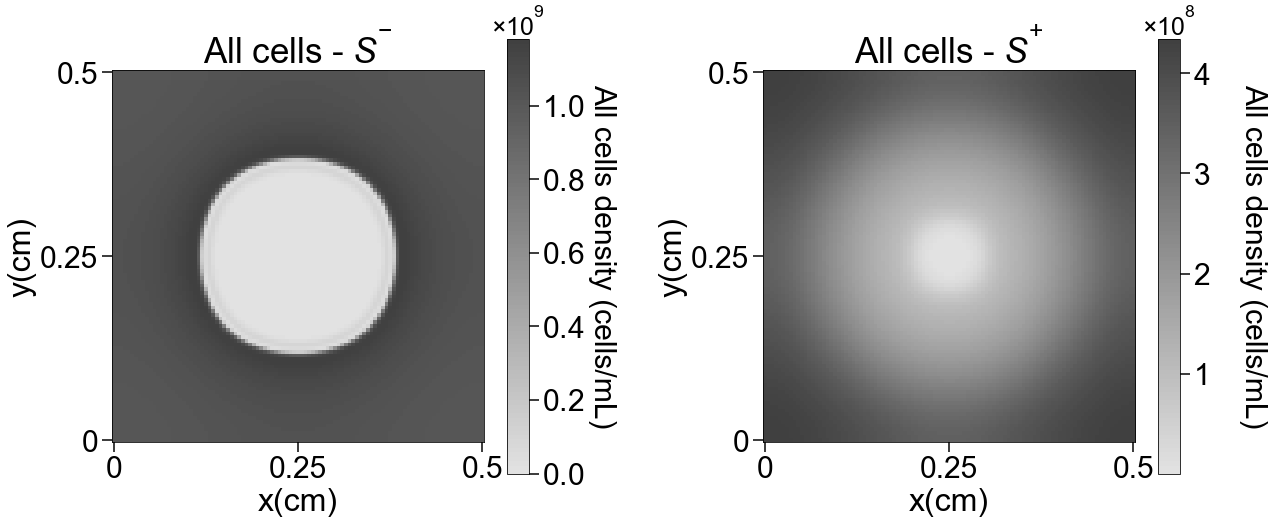

In [13]:
'''Impact of sporulation on plaque size'''
fig, ax = plt.subplots(1, 2, figsize=[20, 8])
ax = np.ravel(ax)
step = 1500

plt.subplots_adjust(wspace=0.4)  # Increase spacing between figures

# Get the 'Greys' colormap
greys = plt.get_cmap('Greys_r')

# Extract colors from the existing colormap
light_grey = greys(0.8)  # Extract lighter grey (closer to white)
less_dark_grey = greys(0.2)  # Extract less dark grey (closer to black)

# Create a custom colormap
colors = [light_grey, less_dark_grey]
n_bins = 100
new_greys = LinearSegmentedColormap.from_list('truncated_greys', colors, N=n_bins)

# Display images with the custom colormap
img1 = ax[0].imshow(All_cells_ND[step], cmap=new_greys)
img2 = ax[1].imshow(All_cells_D[step], cmap=new_greys)

# Add colorbars
cbar1 = fig.colorbar(img1, ax=ax[0], label='All cells density (cells/mL)')
cbar2 = fig.colorbar(img2, ax=ax[1], label='All cells density (cells/mL)')

# Customize colorbar labels and position
for cbar in [cbar1, cbar2]:
    cbar.ax.set_ylabel('All cells density (cells/mL)', fontsize=30, rotation=270, labelpad=40)
    cbar.ax.yaxis.set_label_coords(5, 0.5)
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    cbar.ax.yaxis.set_major_formatter(formatter)
    cbar.ax.yaxis.get_offset_text().set_fontsize(25)
    cbar.ax.yaxis.get_offset_text().set_horizontalalignment('center')
    cbar.ax.yaxis.get_offset_text().set_x(0.5)
    cbar.ax.yaxis.get_offset_text().set_y(1.1)
    cbar.ax.tick_params(labelsize=30)

# Set plot titles and labels
ax[0].set_title('All cells - $S^{-}$', fontsize=35)
ax[1].set_title('All cells - $S^{+}$', fontsize=35)

for a in ax:
    a.set_xlabel('x(cm)', fontsize=32)
    a.set_ylabel('y(cm)', fontsize=32)
    a.tick_params(axis='both', which='major', labelsize=30)

# Define tick positions and labels
tick_positions_x = np.linspace(0, All_cells_ND[step].shape[1]-1, 3)
tick_positions_y = np.linspace(0, All_cells_ND[step].shape[0]-1, 3)
tick_labels = ['0', '0.25', '0.5']

for a in ax:
    a.set_xticks(tick_positions_x)
    a.set_xticklabels(tick_labels)
    a.set_yticks(tick_positions_y)
    a.set_yticklabels(tick_labels)
    a.invert_yaxis()

plt.show()


In [14]:
plaque_size_ND = []
plaque_size_D = []
for i in range(len(t_ev)):
    Sum_ND = 0
    Sum_D = 0
    if t_ev[i] < 2:
        plaque_size_ND.append(Sum_ND)
        plaque_size_D.append(Sum_D)
    else:
        for j in range(int(ls/2), ls):
            if All_cells_ND[i,int(ls/2),j] < np.max(All_cells_ND[i,int(ls/2),:])/10:
                Sum_ND += dx/10000

            if All_cells_D[i,int(ls/2),j] < np.max(All_cells_D[i,int(ls/2),:])/10:
                Sum_D += dx/10000
    
        plaque_size_ND.append(Sum_ND)
        plaque_size_D.append(Sum_D)

In [15]:
'''Experimental data'''
NS_exp_data = scipy.io.loadmat('Sminus_data.mat')['areas']
S_exp_data = scipy.io.loadmat('Splus_data.mat')['areas']
print(NS_exp_data.shape)
NS_areas = NS_exp_data.copy()
NS_exp_plaque_radii = np.sqrt(NS_areas/np.pi)
S_areas = S_exp_data.copy()
S_exp_plaque_radii = np.sqrt(S_areas/np.pi)

NS_exp_plaque_radii_cm = 0.007*NS_exp_plaque_radii
S_exp_plaque_radii_cm = 0.007*S_exp_plaque_radii

time_exp = np.linspace(25/60, (178*5)/60 + 25/60, 179)

NS_mean_radius = np.mean(NS_exp_plaque_radii_cm,1)
S_mean_radius = np.mean(S_exp_plaque_radii_cm,1)

NS_error = np.std(NS_exp_plaque_radii_cm,1)
S_error = np.std(S_exp_plaque_radii_cm,1);

(179, 46)


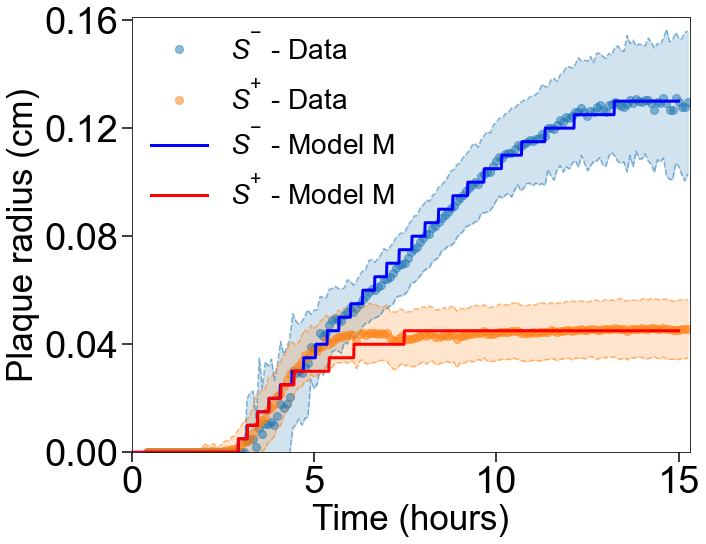

In [16]:
'''Impact of sporulation on plaque size'''
fig, ax = plt.subplots(figsize=[10,8])

# Experimental plots
ax.plot(time_exp, NS_mean_radius, 'o', color='C0', markersize=8, alpha=0.5, label='$S^{-}$ - Data')
ax.fill_between(time_exp, NS_mean_radius - NS_error, NS_mean_radius + NS_error, color='C0', alpha=0.2)
# Add intermittent lines at the upper and lower boundaries
ax.plot(time_exp, NS_mean_radius - NS_error, linestyle='--', color='C0', alpha=0.5)
ax.plot(time_exp, NS_mean_radius + NS_error, linestyle='--', color='C0', alpha=0.5)

ax.plot(time_exp, S_mean_radius, 'o', color='C1', markersize=8, alpha=0.5, label='$S^{+}$ - Data')
ax.fill_between(time_exp, S_mean_radius - S_error, S_mean_radius + S_error, color='C1', alpha=0.2)
# Add intermittent lines at the upper and lower boundaries
ax.plot(time_exp, S_mean_radius - S_error, linestyle='--', color='C1', alpha=0.5)
ax.plot(time_exp, S_mean_radius + S_error, linestyle='--', color='C1', alpha=0.5)

# Theoretical plots
ax.plot(t_ev, plaque_size_ND, color='blue', lw=3, label='$S^{-}$ - Model M')
ax.plot(t_ev, plaque_size_D, color='red', lw=3, label='$S^{+}$ - Model M' )

# Set axis labels and limits
ax.set_xlabel('Time (hours)', fontsize=35)
ax.set_ylabel("Plaque radius (cm)", fontsize=35)
ax.set_xlim([0, 15.3])
ax.set_ylim([0, 0.161])

# Adjust tick size and format
ax.tick_params(axis='both', labelsize=38)

# Adjust legend position and font size
ax.legend(loc='upper left', bbox_to_anchor=(-0.01, 1.02), fontsize=28, frameon=False)

# Set y-ticks with matching style
ax.set_yticks([0, 0.04, 0.08, 0.12, 0.16])

plt.show()

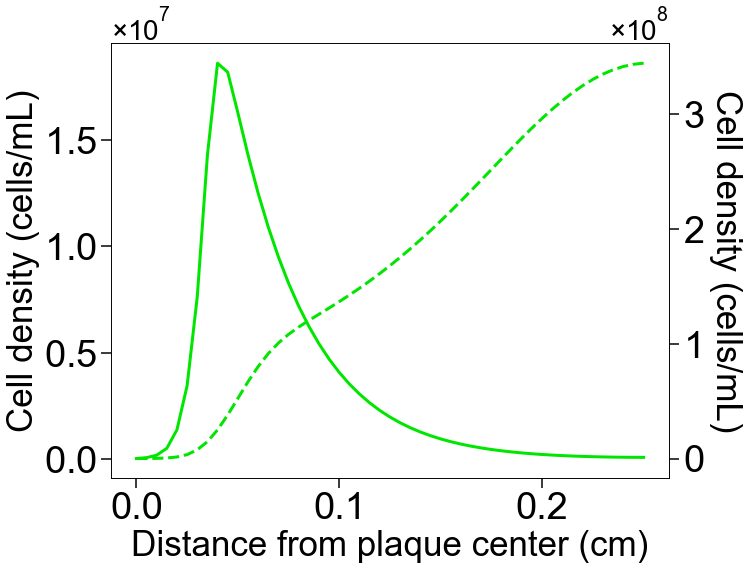

In [17]:
'''Simulated plaque growth and distribution of dormant cells for the $S^{+}$ host'''
step1 = 500
step2 = 1500
fig, ax = plt.subplots(figsize=[10,8])
ax.plot(dx/10000*np.arange(int(ls/2)+1), D_end_D[step1, int(ls/2), int(ls/2):], color=(0, 0.9, 0), lw=3, label='t = 5 hrs')
# Create a second y-axis and plot data on it
ax2 = ax.twinx()
ax2.plot(dx/10000*np.arange(int(ls/2)+1), D_end_D[step2, int(ls/2), int(ls/2):], color=(0, 0.9, 0), linestyle='--', lw=3, label='t = 15 hrs')
ax.set_xlabel('Distance from plaque center (cm)', fontsize=35)
ax.set_ylabel('Cell density (cells/mL)', fontsize=35)
ax.tick_params(axis='both', labelsize=38)
ax2.set_ylabel('Cell density (cells/mL)', fontsize=35)
ax2.tick_params(axis='both', labelsize=38)

# Adjust the right y-axis label and its position
ax2.set_ylabel('Cell density (cells/mL)', fontsize=35, rotation=270)
ax2.yaxis.set_label_coords(1.13, 0.5)  # Adjusted x-coordinate to move the label rightward

# Adjust the format of the tick labels
formatter = ScalarFormatter(useMathText=True)
ax.yaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)
ax.yaxis.offsetText.set_fontsize(28)
ax2.yaxis.offsetText.set_fontsize(28)

# Create a single legend for both lines
# fig.legend(loc='upper left', bbox_to_anchor=(0.42, 0.5), fontsize=35);


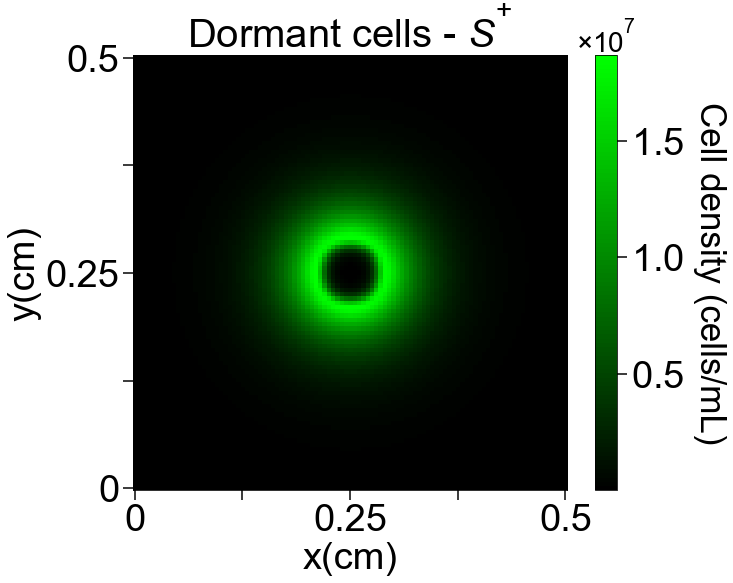

In [18]:
'''Simulated plaque growth and distribution of dormant cells for the $S^{+}$ host'''
fig, ax = plt.subplots(figsize=[10,8])
step = 500

# Define the colors for the custom colormap
colors = [(0, 0, 0), (0, 1, 0)]  # Black to Green
n_bins = 100  # Discretizes the interpolation into bins
cmap_name = 'custom_black_to_green'
new_greens = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

# Display the image with the custom colormap
img = ax.imshow(D_end_D[step], cmap=new_greens)

# Add the colorbar
cbar = fig.colorbar(img, ax=ax, label='Cell density (cells/mL)')

# Change the size, label, and orientation of the right-side label
cbar.ax.set_ylabel('Cell density (cells/mL)', fontsize=35, rotation=270, labelpad=40)  # Adjust labelpad for more distance
cbar.ax.yaxis.set_label_coords(6, 0.5)  # Adjust to move label further right

# Adjust the tick formatter to display scientific notation
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)       # Force scientific notation
formatter.set_powerlimits((-2, 2))   # Customize power limits to always use 10^power
cbar.ax.yaxis.set_major_formatter(formatter)

# Adjust font size and position of the exponent text (scientific notation)
cbar.ax.yaxis.get_offset_text().set_fontsize(28)
cbar.ax.yaxis.get_offset_text().set_horizontalalignment('center')  # Center the text above colorbar
cbar.ax.yaxis.get_offset_text().set_x(0.5)  # Adjust the horizontal position (centered)
cbar.ax.yaxis.get_offset_text().set_y(1.1)  # Adjust vertical position if necessary

# Set the tick parameters for the colorbar
cbar.ax.tick_params(labelsize=38)

# Set plot title and axis labels
ax.set_title('Dormant cells - $S^{+}$', fontsize=40)
ax.set_xlabel('x(cm)', fontsize=38)
ax.set_ylabel('y(cm)', fontsize=38)

# Custom tick labels for the x and y axes
labelsy = [str(0), '', str(0.25), '', str(0.5)]  # Adjusted labels to maintain 0 at the start, 0.25 in the middle, and 0.5 at the end
labelsx = [str(0), '', str(0.25), '', str(0.5)]  # Similar adjustment for the x-axis

# Set the ticks for the x and y axes
ax.set_yticks([0, int(D_end_D.shape[1]/4), int(D_end_D.shape[1]/2), int(3*D_end_D.shape[1]/4), D_end_D.shape[1] - 1])
ax.set_xticks([0, int(D_end_D.shape[2]/4), int(D_end_D.shape[2]/2), int(3*D_end_D.shape[2]/4), D_end_D.shape[2] - 1])

ax.set_yticklabels(labelsy)
ax.set_xticklabels(labelsx)

# Increase tick label size
ax.tick_params(axis='both', which='major', labelsize=38)  # Set labelsize to 38 for both x and y axes
cbar.ax.tick_params(labelsize=38)  # Increase label size for the colorbar ticks as well

# Invert the y-axis
plt.gca().invert_yaxis();